In [5]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [6]:
import pandas as pd

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the FlightNumber (indicating the continuous launch attempts.) and Payload variables would affect the launch outcome.

We can plot out the FlightNumber vs. PayloadMassand overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.

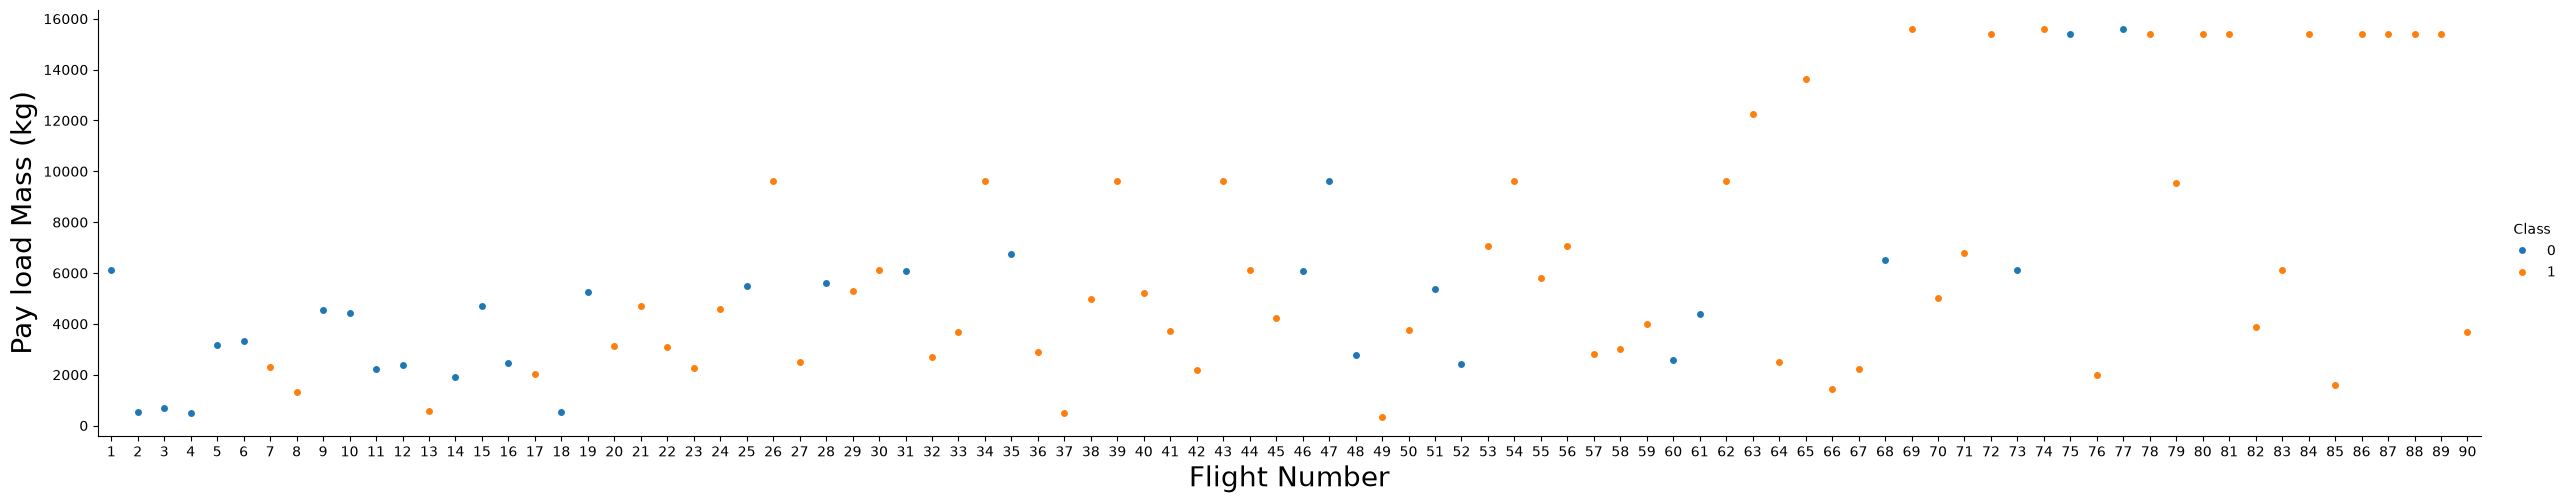

In [10]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

* **TASK 1** : Visualize the relationship between Flight Number and Launch Site
Use the function catplot to plot FlightNumber vs LaunchSite, set the parameter x parameter to FlightNumber,set the y to Launch Site and set the parameter hue to 'class'



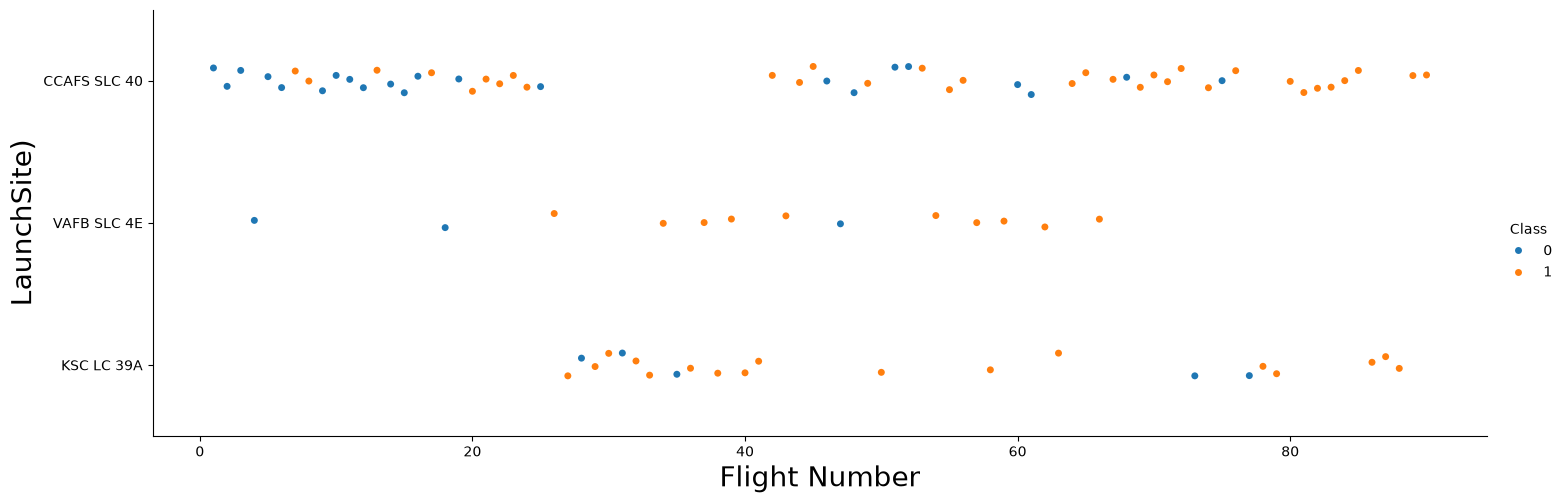

In [36]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 3)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("LaunchSite)",fontsize=20)
plt.show()


* **Facility Expansion:** Launch sites evolved over time, starting with CCAFS SLC 40 for early flights and later integrating KSC LC 39A for higher-cadence missions.
* **Reliability & Maturity:** Later flight numbers show a higher concentration of successes (Class `1`), reflecting improved operational techniques and reliability as the program matured.

* **TASK 2**: Visualize the relationship between Payload Mass and Launch Site
We also want to observe if there is any relationship between launch sites and their payload mass.

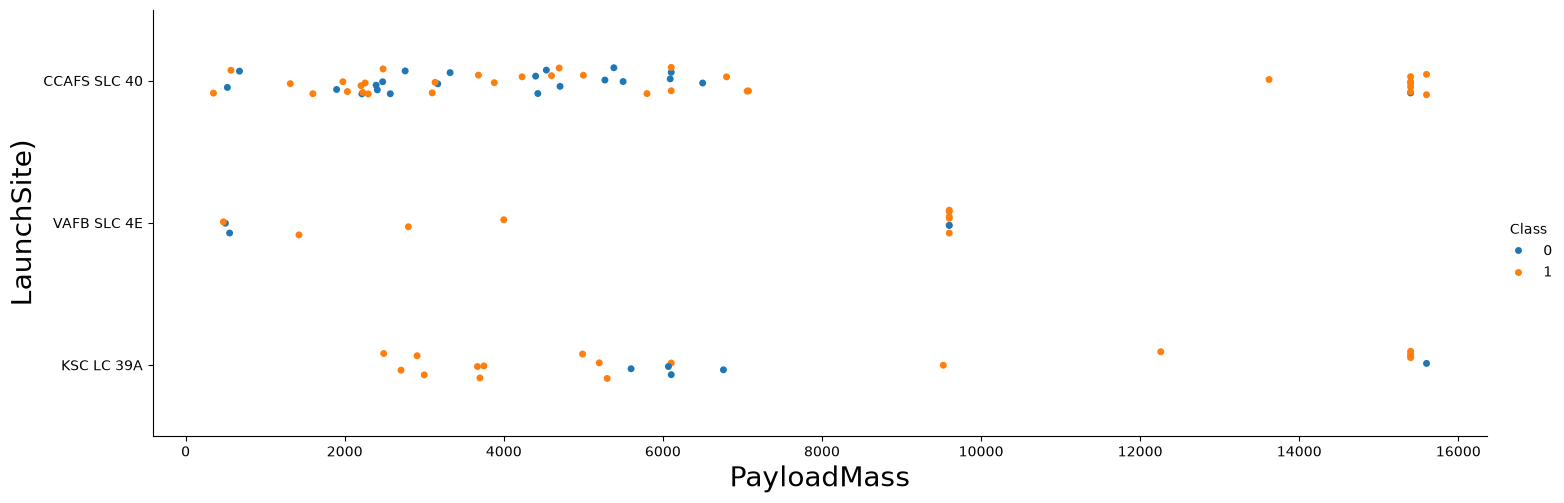

In [23]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value


sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect = 3)
plt.xlabel("PayloadMass",fontsize=20)
plt.ylabel("LaunchSite)",fontsize=20)
plt.show()

* **Payload Distribution by Site:** KSC LC 39A and CCAFS SLC 40 handle the heaviest payloads (exceeding 10,000 kg up to ~15,000+ kg, typical for large constellations like Starlink), whereas VAFB SLC 4E is used for low-to-medium payloads (generally under 10,000 kg, often for polar orbits).
* **Success Rate & Weight Correlation:** Lower-mass payloads exhibit a mixed success rate with both successful and failed landings, while heavy payloads (> 10,000 kg) predominantly result in successful outcomes.
* **Operational Capabilities:** Site selection strongly aligns with payload weight classes and orbital trajectory requirements, reflecting the specialized scaling of SpaceX's launch infrastructure.

In [49]:
corr_matrix["Class"].sort_values(ascending=False)

Class                                  1.000000e+00
Legs                                   6.738249e-01
Outcome_True ASDS                      6.468132e-01
GridFins                               6.425396e-01
ReusedCount                            4.665836e-01
Block                                  4.160149e-01
FlightNumber                           4.019226e-01
LandingPad_5e9e3032383ecb6bb234e7ca    3.223292e-01
Outcome_True RTLS                      3.034885e-01
LandingPad_5e9e3032383ecb267a34e7c7    2.234951e-01
LandingPad_5e9e3033383ecbb9e534e7cc    2.080126e-01
Reused                                 2.075819e-01
PayloadMass                            1.999916e-01
Orbit_VLEO                             1.734220e-01
Outcome_True Ocean                     1.714986e-01
Orbit_SSO                              1.714986e-01
Flights                                1.497871e-01
LaunchSite_KSC LC 39A                  1.279727e-01
LandingPad_5e9e3032383ecb554034e7c9    1.066004e-01
Latitude    

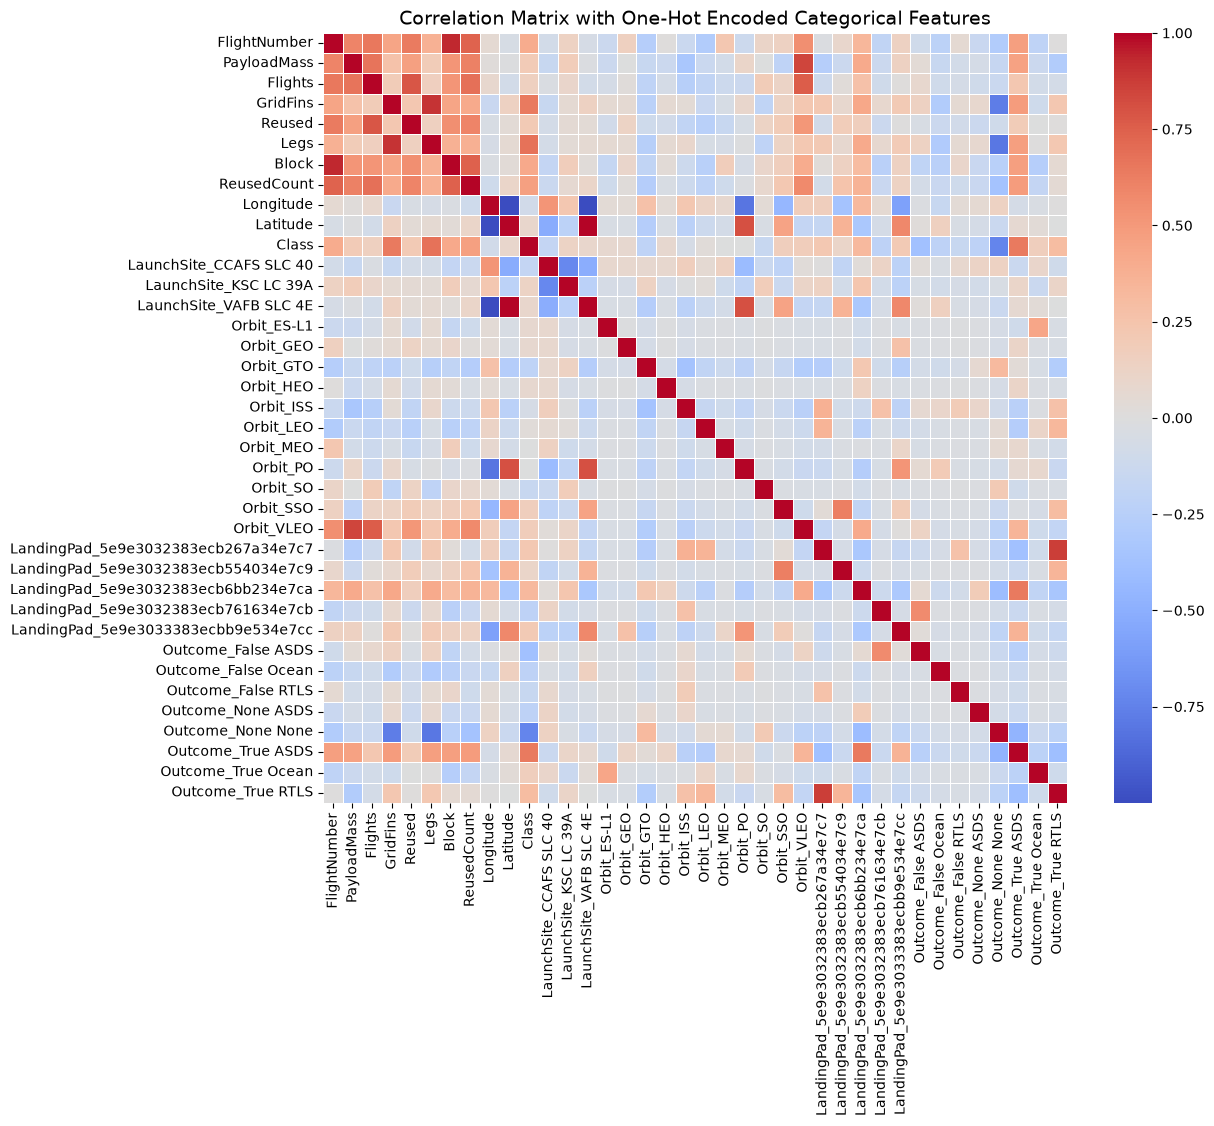

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df, columns=["LaunchSite", "Orbit", "LandingPad", "Outcome"]
)

# Keep only numeric and boolean columns (drops Date, BoosterVersion, etc.)
numeric_encoded = df_encoded.select_dtypes(include=["number", "bool"])

# Compute the correlation matrix safely
corr_matrix = numeric_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title(
    "Correlation Matrix with One-Hot Encoded Categorical Features", fontsize=14
)
plt.show()

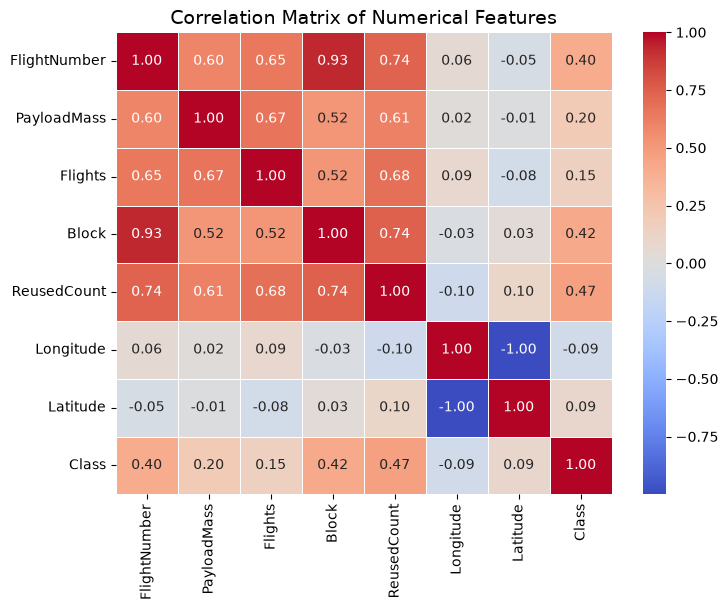

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=["float64", "int64"])

# Create the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.show()

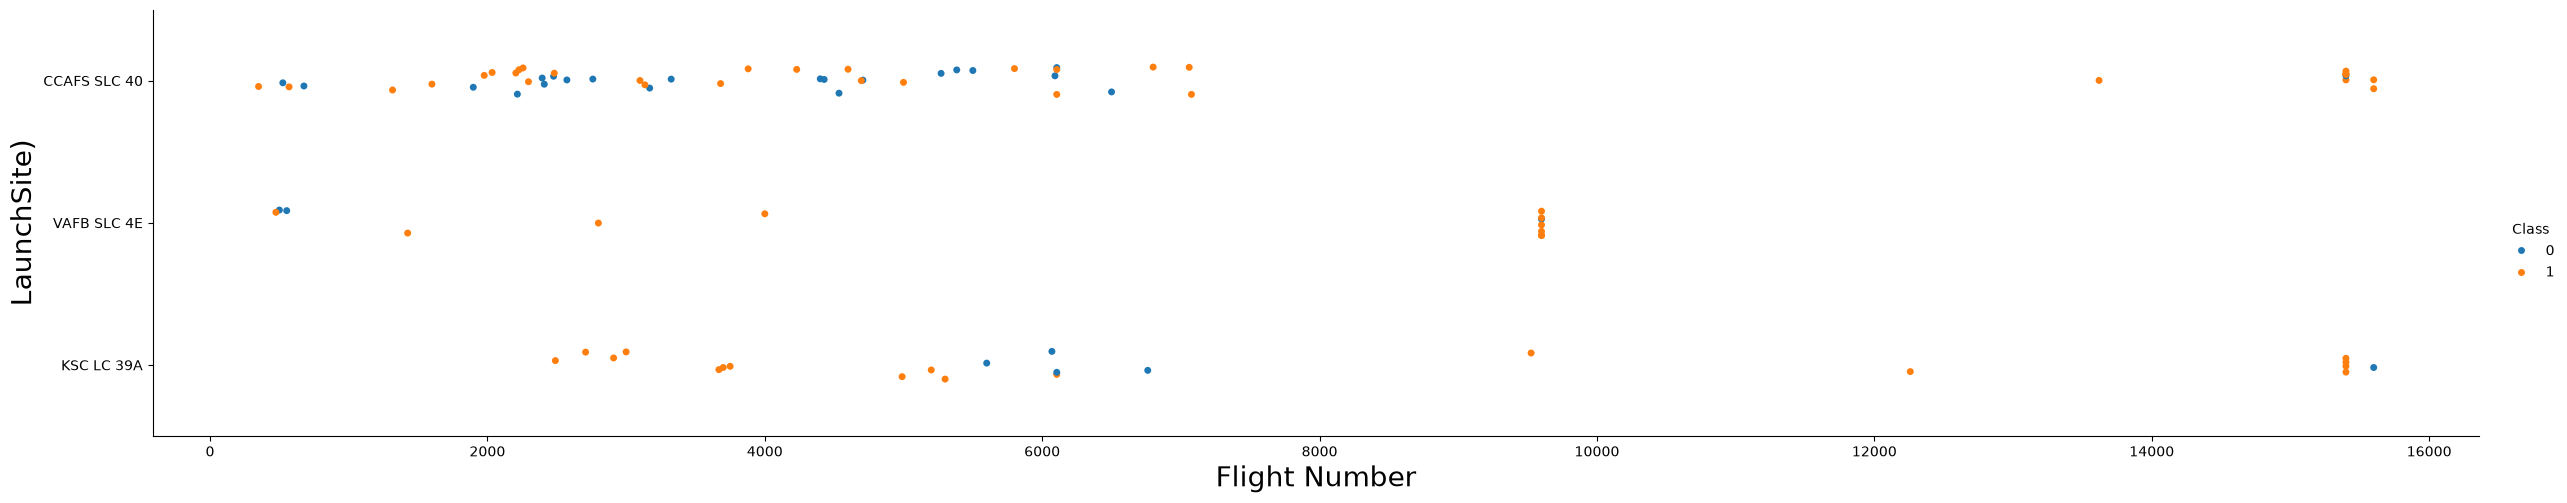

In [26]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value


sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("LaunchSite)",fontsize=20)
plt.show()

* **TASK 3**: Visualize the relationship between success rate of each orbit type
Next, we want to visually check if there are any relationship between success rate and orbit type.

Let's create a bar chart for the sucess rate of each orbit



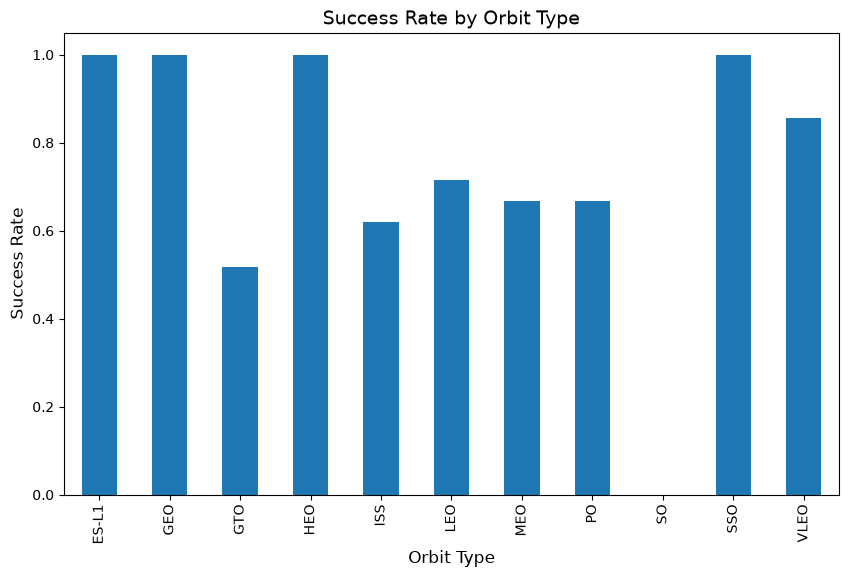

In [57]:
# Group by Orbit and calculate the average success rate
orbit_success = df.groupby("Orbit")["Class"].mean()

# Plot the bar chart
orbit_success.plot(kind='bar', figsize=(10, 6))

plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("Success Rate by Orbit Type", fontsize=14)
plt.show()

### Success Rate by Orbit Type

* **100% Success Orbits:** ES-L1, GEO, ISS, and SSO achieve a perfect success rate of 1.0.
* **Moderate Success Orbits:** GTO (~ 52%), LEO (~ 62%), MEO (~ 66%), and PO (~ 66%) show lower success rates
* **High Success Orbits:** VLEO maintains a strong success rate of approximately 85%.

---

### Inferences

* **Mission Complexity & Energy Demands:** Orbits requiring higher energy profiles (such as GTO) exhibit lower success rates, often due to more demanding booster landing and recovery constraints.
* **Standardization & High Cadence:** Routine destinations like the ISS and SSO benefit from standardized, repetitive flight profiles, leading to consistent success rates.

TASK 4: Visualize the relationship between FlightNumber and Orbit type
For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.

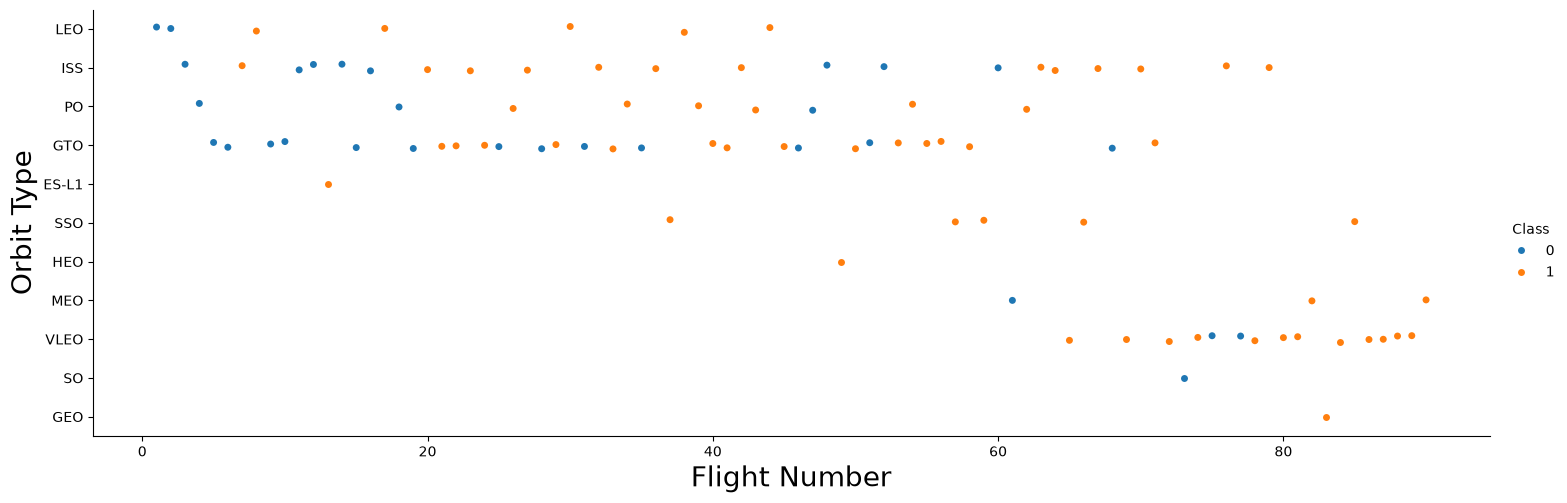

In [38]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

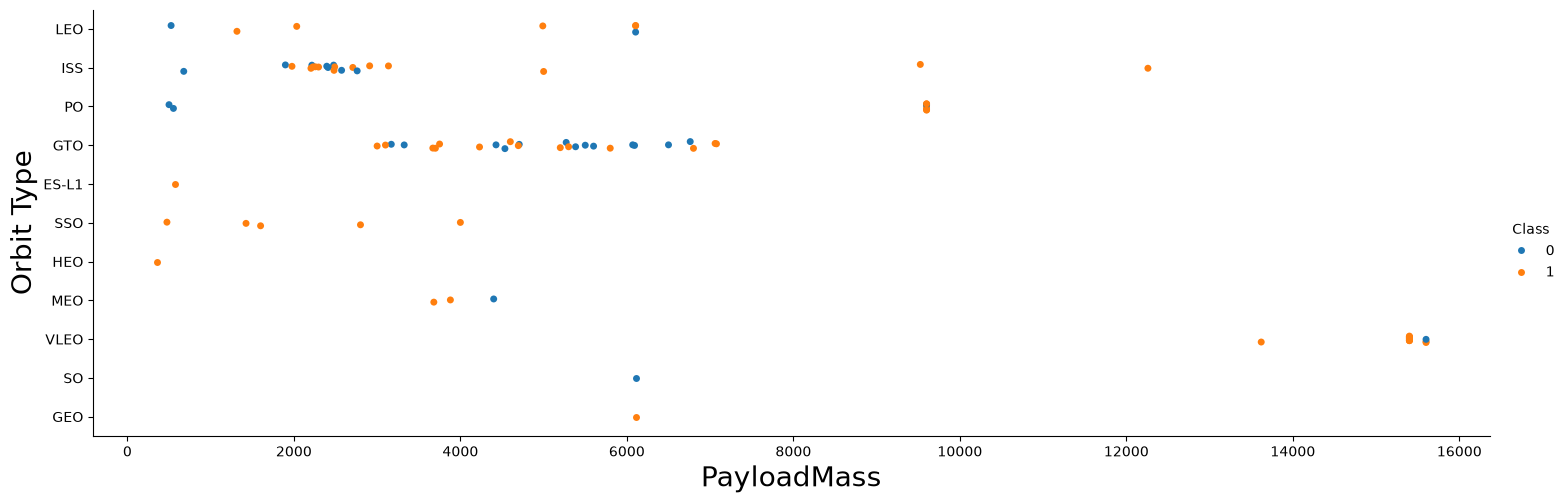

In [42]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value

sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=3)
plt.xlabel("PayloadMass", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

TASK 6: Visualize the launch success yearly trend
You can plot a line chart with x axis to be Year and y axis to be average success rate, to get the average launch success trend.

The function will help you get the year from the date:



In [74]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


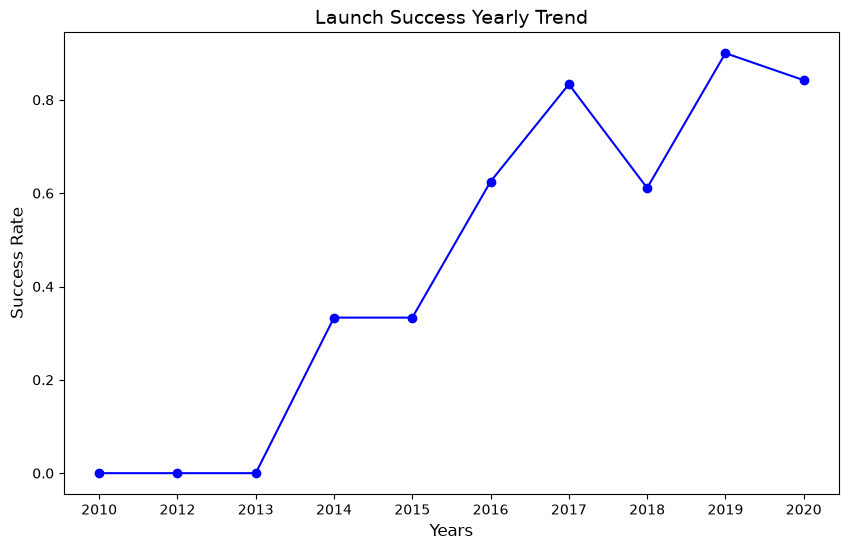

In [83]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate

# Group by the extracted year and calculate the average success rate
yearly_success = df.groupby("Date")["Class"].mean()

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line with markers for clarity
ax.plot(yearly_success.index, yearly_success.values, marker="o", color="b")

# Setting up the Title and Labels
ax.set_title("Launch Success Yearly Trend", fontsize=14)
ax.set_xlabel("Years", fontsize=12)
ax.set_ylabel("Success Rate", fontsize=12)

# Display the plot
plt.show()

Features Engineering
By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()


In [86]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


TASK 7: Create dummy variables to categorical columns¶
Use the function get_dummies and features dataframe to apply OneHotEncoder to the column Orbits, LaunchSite, LandingPad, and Serial. Assign the value to the variable features_one_hot, display the results using the method head. Your result dataframe must include all features including the encoded ones.

In [97]:
features_one_hot = pd.get_dummies(features, columns=["Orbit", "LaunchSite", "LandingPad", "Serial"])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


TASK 8: Cast all numeric columns to float64
Now that our features_one_hot dataframe only contains numbers, cast the entire dataframe to variable type float64



In [100]:
features_one_hot = features_one_hot.astype("float64")
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
features_one_hot.to_csv("dataset_part_3.csv", index=False)